# แผนที่สนับสนุนการนำเสนอ Pattern ใกล้เพดาน ปีงบประมาณ 2569

Notebook นี้ต่อยอดจาก Notebook ของ Pae โดยใช้ **รายการจ้างก่อสร้าง วิธีเฉพาะเจาะจง วงเงินไม่เกิน 500,000 บาท** และวาดตำแหน่งจาก **Longitude/Latitude** ลงบน GeoJSON จังหวัดประเทศไทย

แผนที่มี 3 ชุด:

1. หน่วยงาน Top 3 ตามจำนวนรายการ **Pattern 1**
2. ผู้รับจ้าง Top 3 ตามจำนวนรายการ **Pattern 1** โดยใช้เลขประจำตัว 13 หลักเป็นตัวระบุหลัก
3. หน่วยงาน Top 3 ตามมูลค่าสัญญารวมในกลุ่มศึกษา และผู้รับจ้าง Top 3 ภายในแต่ละหน่วยงานตามจำนวน Pattern 1

เหตุผลที่แผนที่ 1–2 ไม่เรียงด้วยมูลค่ารวม: รายการ Pattern 1 อยู่ในช่วง 490,000–500,000 บาท มูลค่าต่อรายการใกล้กันมาก จำนวนรายการจึงสะท้อน “การเกิดซ้ำ” ตามคำถามของ Pae ได้ตรงกว่า ส่วนสัดส่วนและมูลค่ายังคงแสดงเป็นข้อมูลประกอบเพื่อไม่ให้จำนวนดิบถูกตีความลำพัง

> ผลลัพธ์เป็นเครื่องมือจัดลำดับตรวจเอกสาร ไม่ใช่คะแนนทุจริตหรือหลักฐานการกระทำผิด  
> แหล่งนิยามโครงการ: https://github.com/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/README.md

**Version note:** README ยังบันทึกผลจากนิยามรุ่นก่อนที่ใช้ `ชื่อหน่วยงานย่อย–ผู้รับจ้าง` และ Priority รวม Pattern 3 แต่ Notebook 04 กับ CSV ในโฟลเดอร์ processed รุ่นปัจจุบันใช้ `ชื่อหน่วยงาน–ผู้รับจ้าง` และ Priority = `Pattern 1 AND Pattern 2` ดังนั้น Notebook แผนที่นี้ยึด Code ที่รันจริงและตรวจยอด 136,122 / 9,413 / 1,915 / 205 ก่อนวาดกราฟ เพื่อไม่ผสมผลคนละรุ่น


> **ผลลัพธ์ตัวอย่าง:** รูปและตารางด้านล่างมาจากไฟล์ที่ผู้จัดทำรันบน Google Colab และส่งมาใน `notebook_with_results` สามารถเปิดดูได้โดยไม่ต้องรันใหม่ โค้ดคำนวณยังคงเดิม ผลเมื่อรันใหม่ขึ้นกับข้อมูลและการตั้งค่าที่ใช้


## วิธีรันเวอร์ชัน GitHub

เปิด Notebook นี้ใน Google Colab แล้วเลือก **Runtime → Run all** ข้อมูลจะอ่านจาก [data_for_github](https://drive.google.com/drive/folders/1ssVrUcY4TiYee9T2B0pwgr5SwvPp_lAq) โดยดาวน์โหลดเฉพาะไฟล์ที่ใช้ลงพื้นที่ชั่วคราวของ Runtime ไม่ต้องตั้งโฟลเดอร์ผลลัพธ์หรือเชื่อม Drive ส่วนตัว

- กราฟและตารางแสดงใน Notebook ไม่มีการส่งออก CSV/PNG/SVG ไปยัง Drive หรือเครื่องของผู้อ่าน
- ไฟล์ข้อมูล ฟอนต์ แผนที่ และ CSV พักที่จำเป็นอยู่ใน Runtime เท่านั้น เซลล์สุดท้ายลบไฟล์พักและเก็บ DataFrame ไว้ให้วิเคราะห์ต่อ หากหยุดกลางทางให้รัน `cleanup_runtime()` เมื่อไม่ต้องใช้ไฟล์พักแล้ว
- รันแต่ละ Notebook ใน Runtime แยกกันเพื่อลด RAM; หาก RAM ใช้ถึง 80% โค้ดจะหยุดพร้อมคำแนะนำ แทนการฝืนประมวลผล
- กรณี Drive จำกัดการดาวน์โหลด ให้ดาวน์โหลดข้อมูลเองและระบุ `LOCAL_DATA_DIR` ในเซลล์ตั้งค่า
- สูตร เกณฑ์ ตัวกรอง และลำดับข้อมูลคงตามไฟล์ต้นฉบับ อ่านข้อแตกต่างระหว่าง Notebook และรายการไฟล์ใน [DATA_FILES.md](../DATA_FILES.md)

ผลลัพธ์เดิมที่ฝังในไฟล์ถูกล้างเพื่อให้ผู้อ่านเห็นผลจากการรันครั้งใหม่


In [40]:
# GitHub / Colab: ดาวน์โหลดข้อมูลเฉพาะที่ใช้ลงพื้นที่ชั่วคราว ไม่ต้อง Mount Drive
# เปลี่ยนเป็น Path โฟลเดอร์ข้อมูลที่มีอยู่แล้วได้ เพื่อไม่ต้องดาวน์โหลดซ้ำ
LOCAL_DATA_DIR = None
import atexit
import gc
import hashlib
import importlib.util
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

# ติดตั้งเฉพาะแพ็กเกจที่ยังไม่มี; subprocess นี้รอจนจบ ไม่มี worker ค้าง
_packages = {"pandas": "pandas>=2.2,<3", "numpy": "numpy", "matplotlib": "matplotlib", "seaborn": "seaborn", "geopandas": "geopandas", "psutil": "psutil", "gdown": "gdown", "IPython": "ipython"}
_missing_packages = [requirement for module, requirement in _packages.items() if importlib.util.find_spec(module) is None]
if _missing_packages:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_missing_packages], check=True)
import psutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown
from IPython.display import display

def check_memory(stage="ประมวลผล"):
    # หยุดอย่างชัดเจนเมื่อ RAM สูง แทนการฝืนจน Runtime หลุด
    if psutil.virtual_memory().percent >= 80:
        gc.collect()
        if psutil.virtual_memory().percent >= 80:
            raise MemoryError(f"RAM ใช้เกิน 80% ก่อน {stage}; กรุณา Restart runtime หรือใช้ High-RAM แล้ว Run all ใหม่")

# รัน setup ซ้ำจะปิดพื้นที่ชั่วคราวของ Notebook รอบก่อน
if "_github_runtime" in globals():
    _github_runtime.cleanup()
_github_runtime = tempfile.TemporaryDirectory(prefix="procurement_github_")
atexit.register(_github_runtime.cleanup)
RUNTIME_DIR = Path(_github_runtime.name)
DATA_DIR = RUNTIME_DIR / "inputs"
DATA_DIR.mkdir()
_initial_figure_numbers = set(plt.get_fignums())

DATA_FILES = {
    "07_lower10_project_budget_2567.csv": {
        "id": "1YQpAhUcghJ9gM6eIC6qBZGe6WcVuKyWR",
        "size": 4169
    },
    "07_lower10_project_budget_2568.csv": {
        "id": "1aNYIMOH7Da8VvVhXI1XQigBYRNWk9IHj",
        "size": 5098
    },
    "07_lower10_project_budget_2569.csv": {
        "id": "1tU1V9n2ysJmXxvmnm_SPz7n7Bhbz2B5_",
        "size": 4371
    },
    "07_top10_project_budget_2567.csv": {
        "id": "1bkMYSpLM4UKivKCHe7S8Dsho0BaLgCdJ",
        "size": 5619
    },
    "07_top10_project_budget_2568.csv": {
        "id": "1xsItnomfe9q4A9NYJ5U_lR0764mZMEE4",
        "size": 5682
    },
    "07_top10_project_budget_2569.csv": {
        "id": "1ZwOBFVQkTRAnazjoeXzr3jkpSGFl2bkI",
        "size": 6385
    },
    "2569-egp-contract-1.csv": {
        "id": "1ygmuKsvVjNpjfg0k94Olcuox8efDP3cY",
        "size": 615601896
    },
    "2569-egp-contract-2.csv": {
        "id": "1DUAh8zAtUUV4Hm2yRplCryUOQDFb3Ad8",
        "size": 542097077
    },
    "2569-egp-contract-3.csv": {
        "id": "1fD_6GqtIY7LUempYqId0qIEldcJd2moM",
        "size": 529193616
    },
    "2569-egp-contract-4.csv": {
        "id": "19C4Ak8XNMvm2IBsr7TVpfexZE_1WBke5",
        "size": 526729581
    },
    "2569-egp-contract-5.csv": {
        "id": "1nsV7vqF8Um-QWKX_Q-kEQq6Z1BFDbK_y",
        "size": 521850128
    },
    "2569-egp-contract-6.csv": {
        "id": "1-0zhDZjF2chjeXuPoSVGQWNYtp8fVIzt",
        "size": 522697146
    },
    "2569-egp-contract-7.csv": {
        "id": "1gl9sx_1ve-n7e9M_mQaj0A7mMnk2P0yb",
        "size": 517466336
    },
    "2569-egp-contract-8.csv": {
        "id": "1z0icf65DY2e7WPmc_qV5PPLdUVyT1wdR",
        "size": 455588827
    },
    "construction_contract_review_indicators_2569.csv": {
        "id": "1nYgjub4kfLTyX_9gnz3dM2GZWUM67wRJ",
        "size": 247613515
    },
    "construction_contract_supplier_study_scope_2569.csv": {
        "id": "1dXH9N4ukZAabRQwl9nkQ-KidB1e80ZAh",
        "size": 243311179
    },
    "priority_review_contracts_2569.csv": {
        "id": "1prDQwSgkNCFqarTx0rkFuQK12Q5J2MT_",
        "size": 108598
    },
    "project_overview_2567.csv": {
        "id": "1hEr6tXWRBgEM-uK0dOEKvzIhBdKzHtnx",
        "size": 1685455822
    },
    "project_overview_2568.csv": {
        "id": "1WVh1etQtH45AemJE4J7mBCDOOT9QmQff",
        "size": 1448461110
    },
    "project_overview_2569.csv": {
        "id": "1h3Oah1ARYenycAJnLa1DTefzjMryQuJ5",
        "size": 1227718817
    },
    "repeated_near_500k_agency_supplier_2569.csv": {
        "id": "10fT6PqZbBa5mS4GEHHEOf8_qIeASToQk",
        "size": 364037
    }
}

def data_file(name):
    # ใช้ไฟล์ในเครื่องก่อนถ้าผู้ใช้ระบุโฟลเดอร์ โดยไม่แก้ไขไฟล์ต้นฉบับ
    if LOCAL_DATA_DIR is not None:
        candidate = Path(LOCAL_DATA_DIR) / name
        if candidate.is_file():
            return candidate
    if name not in DATA_FILES:
        raise FileNotFoundError(f"ยังไม่มีข้อมูล {name} ในชุดที่แชร์ กรุณาตรวจ DATA_FILES หรือ LOCAL_DATA_DIR")
    item = DATA_FILES[name]
    target = DATA_DIR / name
    if target.is_file():
        return target
    required_bytes = int(item["size"])
    if shutil.disk_usage(DATA_DIR).free < required_bytes + 512 * 1024**2:
        raise OSError(f"พื้นที่ชั่วคราวไม่พอสำหรับ {name}")
    partial = target.with_suffix(target.suffix + ".part")
    print(f"อ่านข้อมูล {name} ({required_bytes / 1024**2:,.1f} MB)")
    try:
        result = gdown.download(id=item["id"], output=str(partial), quiet=False)
        if result is None or not partial.is_file() or partial.stat().st_size != required_bytes:
            raise IOError(f"ดาวน์โหลด {name} ไม่ครบ หรือไฟล์ใน Drive เปลี่ยนรุ่น")
        if item.get("md5"):
            digest = hashlib.md5()
            with partial.open("rb") as stream:
                for block in iter(lambda: stream.read(4 * 1024**2), b""):
                    digest.update(block)
            if digest.hexdigest() != item["md5"]:
                raise IOError(f"Checksum ไม่ตรงสำหรับ {name}")
        partial.replace(target)
    except Exception as exc:
        partial.unlink(missing_ok=True)
        raise RuntimeError(f"อ่าน {name} ไม่สำเร็จ: ตรวจสิทธิ์ Anyone with the link ของโฟลเดอร์ข้อมูล หรือดาวน์โหลดเองแล้วกำหนด LOCAL_DATA_DIR") from exc
    return target

def release_download(path):
    # ลบเฉพาะสำเนาที่ Notebook นี้ดาวน์โหลด ไม่ลบไฟล์ใน LOCAL_DATA_DIR
    path = Path(path)
    if path.parent == DATA_DIR:
        path.unlink(missing_ok=True)

def cleanup_runtime():
    # เก็บ DataFrame ผลวิเคราะห์ไว้ให้ย้อนกลับมาดูต่อได้
    for number in set(plt.get_fignums()) - _initial_figure_numbers:
        plt.close(number)
    _github_runtime.cleanup()
    gc.collect()
    print("ปิดรูปและลบไฟล์พักของ Notebook แล้ว; DataFrame ผลวิเคราะห์ยังอยู่ใน RAM")

check_memory("เริ่ม Notebook")



## 1. Setup และเชื่อม Google Drive

In [41]:
# ============================================================
# 1) SETUP : เชื่อม Google Drive และ Import Library
# ============================================================

# GitHub: ใช้ข้อมูลจากลิงก์ที่แชร์ ไม่ต้อง Mount Drive
import gc
import textwrap
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects
from IPython.display import display

plt.close('all')


## 2. Parameters และตำแหน่งไฟล์

In [42]:
# ============================================================
# 2) PARAMETERS : แก้ YEAR จุดเดียวเมื่อต้องการใช้ปีอื่น
# ============================================================

YEAR = 2569

# หากตำแหน่งจริงไม่ตรงกับ Candidate ให้ใส่ Path โฟลเดอร์ processed ที่นี่
# ตัวอย่าง: PROCESSED_DIR_OVERRIDE = Path('/content/drive/MyDrive/egp-contract/processed')
PROCESSED_DIR_OVERRIDE = None

# True = บันทึก PNG และ SVG, False = แสดงรูปใน Notebook อย่างเดียว
SAVE_FIGURES = False  # แสดงกราฟอย่างเดียว
PNG_DPI = 320

# ขนาดจุดเป็น "พื้นที่วงกลม" ในหน่วย points^2 และตั้งให้เล็กเพื่อไม่บดบังแผนที่
MIN_POINT_AREA = 12
MAX_POINT_AREA = 180
MAX_BUDGET_FOR_SIZE = 500_000

# Zoom ตาม Min/Max ของจุด พร้อม Padding และไม่ซูมแคบกว่าพื้นที่ประมาณหนึ่งจังหวัด
ZOOM_PADDING_RATIO = 0.10
ZOOM_PADDING_DEGREES = 0.18
MIN_ZOOM_SPAN_LONGITUDE = 1.20
MIN_ZOOM_SPAN_LATITUDE = 1.20
PROVINCE_LABEL_SIZE = 9
MAX_PROVINCE_LABELS = 20

# ยอดควบคุมจาก Notebook 02 และ 04 ของ Pae รุ่นปัจจุบัน
EXPECTED_COUNTS = {
    'Study scope': 136_122,
    'Pattern 1': 9_413,
    'Pattern 2': 1_915,
    'Priority P1 AND P2': 205,
}

REQUIRED_FILENAMES = [
    f'construction_contract_review_indicators_{YEAR}.csv',
]

# อ่าน snapshot จากชุดข้อมูลที่แชร์ โดยไม่ผูกกับ My Drive ของเจ้าของโครงการ
PROCESSED_DIR = DATA_DIR
REVIEW_FILE = data_file(f'construction_contract_review_indicators_{YEAR}.csv')

# รูปจะอยู่ข้างโฟลเดอร์ processed และไม่สร้าง CSV เพิ่ม
FIGURE_DIR = RUNTIME_DIR
if SAVE_FIGURES:
    pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

print(f'ปีงบประมาณ: {YEAR}')
print(f'✅ ไฟล์ข้อมูล: {REVIEW_FILE}')
print(f'✅ โฟลเดอร์รูป: {FIGURE_DIR}')
print(f'บันทึกรูป: {SAVE_FIGURES}')


อ่านข้อมูล construction_contract_review_indicators_2569.csv (236.1 MB)


ปีงบประมาณ: 2569
✅ ไฟล์ข้อมูล: /tmp/procurement_github_dzhli057/inputs/construction_contract_review_indicators_2569.csv
✅ โฟลเดอร์รูป: /tmp/procurement_github_dzhli057
บันทึกรูป: False


## 3. ฟอนต์ Theme และฟังก์ชันช่วย

In [43]:
# ============================================================
# 3) FONT AND STYLE : ฟอนต์ไทยและ Theme กลาง
# ============================================================

font_path = RUNTIME_DIR / 'NotoSansThai.ttf'
font_url = (
    'https://raw.githubusercontent.com/google/fonts/main/'
    'ofl/notosansthai/NotoSansThai%5Bwdth%2Cwght%5D.ttf'
)
if not font_path.exists():
    urllib.request.urlretrieve(font_url, font_path)

font_manager.fontManager.addfont(font_path)
THAI_FONT = font_manager.FontProperties(fname=font_path).get_name()

# ขนาดตัวอักษรทุกส่วนไม่น้อยกว่า 15 ยกเว้นไม่มีการแสดงชื่อจังหวัดในแผนที่นี้
plt.rcParams.update({
    'font.family': THAI_FONT,
    'font.size': 15,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'legend.fontsize': 15,
    'legend.title_fontsize': 15,
    'figure.titlesize': 25,
    'axes.unicode_minus': False,
})

BACKGROUND = '#F7F9FC'
MAP_FILL = '#E8EDF3'
BOUNDARY_COLOR = '#7A8795'
TITLE_COLOR = '#19324D'
TEXT_COLOR = '#344054'
MUTED_COLOR = '#667085'
ENTITY_COLORS = ['#24557F', '#D9822B', '#16877C']
SUPPLIER_COLORS = ['#24557F', '#E0703C', '#1B8A7A']


In [44]:
# ============================================================
# 4) HELPER FUNCTIONS : RAM, ชนิดข้อมูล, ขนาดจุด และการบันทึกรูป
# ============================================================

def print_memory(label):
    # ตรวจ RAM ก่อน operation ใหญ่ เพื่อหลีกเลี่ยงการใช้ pagefile หรือ Colab crash
    try:
        import psutil
        memory = psutil.virtual_memory()
        print(f'RAM {label}: {memory.percent:.1f}% | available {memory.available / 1024**3:,.1f} GB')
        return float(memory.percent)
    except Exception:
        return np.nan


def require_memory_below(limit=80.0):
    used = print_memory('ก่อน operation ขนาดใหญ่')
    if pd.notna(used) and used >= limit:
        gc.collect()
        used_after = print_memory('หลัง gc.collect()')
        if used_after >= limit:
            raise MemoryError(
                f'RAM ใช้อยู่ {used_after:.1f}% สูงกว่าเกณฑ์ {limit:.0f}% '
                'กรุณา Restart session แล้ว Run all ใหม่'
            )


def boolean_series(series):
    # รองรับทั้ง bool จริงและข้อความ True/False จาก CSV
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)
    return series.astype('string').str.strip().str.lower().isin(['true', '1', 'yes', 'y'])


def numeric_series(series):
    # รองรับตัวเลขจริงและข้อความที่มี comma
    return pd.to_numeric(series.astype('string').str.replace(',', '', regex=False), errors='coerce')


def clean_text(series):
    cleaned = series.astype('string').str.strip()
    return cleaned.mask(cleaned.isin(['', '-', 'nan', '<NA>']))


def make_supplier_key(dataframe):
    # ใช้เลข 13 หลักก่อน ถ้าว่างจึงใช้ชื่อ เพื่อไม่รวมคนละบริษัทเพียงเพราะชื่อคล้ายกัน
    supplier_id = clean_text(dataframe['supplier_id'])
    supplier_name = clean_text(dataframe['supplier_name']).fillna('ไม่ทราบชื่อ')
    return supplier_id.fillna('NAME:' + supplier_name)


def wrap_label(value, width=27):
    return '\n'.join(textwrap.wrap(str(value), width=width, break_long_words=False))


def marker_area_from_budget(series):
    # Matplotlib ใช้ s เป็นพื้นที่วงกลม พื้นที่จึงแปรผันเชิงเส้นกับวงเงิน
    amount = numeric_series(series).fillna(0).clip(lower=0, upper=MAX_BUDGET_FOR_SIZE)
    return MIN_POINT_AREA + (amount / MAX_BUDGET_FOR_SIZE) * (MAX_POINT_AREA - MIN_POINT_AREA)


def save_and_show(fig, stem):
    if SAVE_FIGURES:
        png_file = FIGURE_DIR / f'{stem}.png'
        svg_file = FIGURE_DIR / f'{stem}.svg'
        pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์
        pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์
        print(f'✅ PNG: {png_file}')
        print(f'✅ SVG: {svg_file}')
    plt.show()
    plt.close(fig)


def column_from_candidates(header_lookup, candidates, label):
    for candidate in candidates:
        if candidate in header_lookup:
            return header_lookup[candidate]
    raise KeyError(f'ไม่พบคอลัมน์ {label}; รองรับชื่อ: {candidates}')


## 4. โหลดข้อมูลแบบ Memory-safe และตรวจยอดกับ Pae

In [32]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ============================================================
# 5) LOAD DATA : อ่านเฉพาะคอลัมน์ที่ใช้และกรองทีละ Chunk
# ============================================================

require_memory_below()

# อ่านเฉพาะ Header เพื่อรองรับชื่อคอลัมน์พิกัด/วงเงินหลายเวอร์ชัน
header = pd.read_csv(REVIEW_FILE, nrows=0)
header_lookup = {str(column).strip(): column for column in header.columns}

column_map = {
    column_from_candidates(header_lookup, ['รหัสโครงการ'], 'รหัสโครงการ'): 'project_id',
    column_from_candidates(header_lookup, ['เลขที่สัญญา'], 'เลขที่สัญญา'): 'contract_no',
    column_from_candidates(header_lookup, ['ชื่อหน่วยงาน'], 'ชื่อหน่วยงาน'): 'agency',
    column_from_candidates(header_lookup, ['เลขประจำตัวนิติบุคคล 13 หลัก'], 'เลขผู้รับจ้าง'): 'supplier_id',
    column_from_candidates(header_lookup, ['ชื่อผู้ชนะการเสนอราคา'], 'ชื่อผู้รับจ้าง'): 'supplier_name',
    column_from_candidates(
        header_lookup,
        ['วงเงินงบประมาณในสัญญา (บาท)', 'วงเงินงบประมาณ (บาท)'],
        'วงเงินสัญญา',
    ): 'amount',
    column_from_candidates(header_lookup, ['อยู่ในขอบเขตตรวจรูปแบบ'], 'Flag กลุ่มศึกษา'): 'in_scope',
    column_from_candidates(header_lookup, ['flag_pattern_1'], 'flag_pattern_1'): 'flag_pattern_1',
    column_from_candidates(header_lookup, ['flag_pattern_2'], 'flag_pattern_2'): 'flag_pattern_2_exported',
    column_from_candidates(
        header_lookup,
        ['ละติจูดของโครงการ', 'ละติจูด (Latitude)', 'Latitude', 'latitude', 'lat'],
        'Latitude',
    ): 'latitude',
    column_from_candidates(
        header_lookup,
        ['ลองจิจูดของโครงการ', 'ลองจิจูด (Longitude)', 'Longitude', 'longitude', 'lon', 'lng'],
        'Longitude',
    ): 'longitude',
}

# โหลด priority_review ถ้ามี เพื่อใช้ตรวจว่าตรงกับ P1 AND P2 หรือไม่
priority_source_column = header_lookup.get('priority_review')
if priority_source_column is not None:
    column_map[priority_source_column] = 'priority_review_exported'

usecols = list(column_map)
string_columns = [
    source for source, target in column_map.items()
    if target in {
        'project_id', 'contract_no', 'agency', 'supplier_id', 'supplier_name',
        'in_scope', 'flag_pattern_1', 'flag_pattern_2_exported', 'priority_review_exported',
    }
]

scope_parts = []
for chunk in pd.read_csv(
    REVIEW_FILE,
    usecols=usecols,
    dtype={column: 'string' for column in string_columns},
    chunksize=40_000,
    low_memory=True,
):
    chunk = chunk.rename(columns=column_map)
    in_scope_mask = boolean_series(chunk['in_scope'])
    if in_scope_mask.any():
        scope_parts.append(chunk.loc[in_scope_mask].copy())
    del chunk, in_scope_mask

study_df = pd.concat(scope_parts, ignore_index=True)
del scope_parts, header
gc.collect()

# แปลงชนิดข้อมูลหลังกรองแล้ว จึงใช้ RAM ต่ำกว่าการแปลงทั้งไฟล์
for column in ['project_id', 'contract_no', 'agency', 'supplier_id', 'supplier_name']:
    study_df[column] = clean_text(study_df[column])
for column in ['in_scope', 'flag_pattern_1', 'flag_pattern_2_exported']:
    study_df[column] = boolean_series(study_df[column])
if 'priority_review_exported' in study_df.columns:
    study_df['priority_review_exported'] = boolean_series(study_df['priority_review_exported'])
study_df['amount'] = numeric_series(study_df['amount'])
study_df['latitude'] = numeric_series(study_df['latitude'])
study_df['longitude'] = numeric_series(study_df['longitude'])
study_df['supplier_key'] = make_supplier_key(study_df)
study_df['contract_record_id'] = (
    study_df['project_id'].fillna('').str.cat(study_df['contract_no'].fillna(''), sep='|')
    .str.cat(study_df['supplier_key'].fillna(''), sep='|')
)

# Grain ของ Pae ต้องมีหนึ่งแถวต่อ รหัสโครงการ + เลขสัญญา + ผู้รับจ้าง
duplicate_keys = int(study_df['contract_record_id'].duplicated().sum())
if duplicate_keys:
    raise ValueError(f'พบ contract_record_id ซ้ำ {duplicate_keys:,} แถว จึงหยุดเพื่อป้องกันจำนวนถูกนับเกิน')

# คำนวณ Pattern 2 ใหม่ตามสูตรใน Notebook 04 แทนการเชื่อ Flag ที่ export มา
# เหตุผล: CSV ปัจจุบันมี flag_pattern_2_exported ไม่ครบเมื่อเทียบกับการรันสูตรต้นฉบับ
agency_data_df = study_df.loc[
    study_df['agency'].notna() & study_df['supplier_id'].notna()
].copy()

agency_supplier_dependence_all_df = (
    agency_data_df.groupby(['agency', 'supplier_id'], dropna=False)
    .agg(
        supplier_name=('supplier_name', 'first'),
        supplier_record_count=('contract_no', 'size'),
        supplier_value=('amount', 'sum'),
    )
    .reset_index()
)
agency_total_df = (
    agency_data_df.groupby('agency', dropna=False)
    .agg(agency_record_count=('contract_no', 'size'), agency_value=('amount', 'sum'))
    .reset_index()
)
agency_supplier_dependence_all_df = agency_supplier_dependence_all_df.merge(
    agency_total_df, on='agency', how='left', validate='many_to_one'
)
agency_supplier_dependence_all_df['record_share_pct'] = (
    agency_supplier_dependence_all_df['supplier_record_count']
    / agency_supplier_dependence_all_df['agency_record_count'] * 100
)
agency_supplier_dependence_all_df['value_share_pct'] = (
    agency_supplier_dependence_all_df['supplier_value']
    / agency_supplier_dependence_all_df['agency_value'] * 100
)

pattern2_pairs_df = (
    agency_supplier_dependence_all_df.loc[
        agency_supplier_dependence_all_df['supplier_record_count'].ge(10)
        & agency_supplier_dependence_all_df['record_share_pct'].ge(75)
        & agency_supplier_dependence_all_df['value_share_pct'].ge(75)
    ]
    .sort_values(['supplier_record_count', 'record_share_pct'], ascending=False)
    .reset_index(drop=True)
)
pattern2_keys = set(
    pattern2_pairs_df[['agency', 'supplier_id']].itertuples(index=False, name=None)
)
study_df['flag_pattern_2'] = [
    (agency, supplier_id) in pattern2_keys
    for agency, supplier_id in zip(study_df['agency'], study_df['supplier_id'])
]
study_df['priority_p1_and_p2'] = study_df['flag_pattern_1'] & study_df['flag_pattern_2']

# คืน RAM ของตารางกลาง แต่เก็บ pattern2_pairs_df ไว้ตรวจย้อนหลัง
del agency_data_df, agency_supplier_dependence_all_df, agency_total_df, pattern2_keys
gc.collect()

actual_counts = {
    'Study scope': len(study_df),
    'Pattern 1': int(study_df['flag_pattern_1'].sum()),
    'Pattern 2': int(study_df['flag_pattern_2'].sum()),
    'Priority P1 AND P2': int(study_df['priority_p1_and_p2'].sum()),
}
control_summary_df = pd.DataFrame({
    'รายการตรวจ': list(EXPECTED_COUNTS),
    'ยอดจาก Notebook Pae': [EXPECTED_COUNTS[key] for key in EXPECTED_COUNTS],
    'ยอดจาก CSV ปัจจุบัน': [actual_counts[key] for key in EXPECTED_COUNTS],
})
control_summary_df['สถานะ'] = np.where(
    control_summary_df['ยอดจาก Notebook Pae'].eq(control_summary_df['ยอดจาก CSV ปัจจุบัน']),
    'ตรงกัน', 'ไม่ตรงกัน',
)
display(control_summary_df.style.format({
    'ยอดจาก Notebook Pae': '{:,.0f}',
    'ยอดจาก CSV ปัจจุบัน': '{:,.0f}',
}))

if control_summary_df['สถานะ'].ne('ตรงกัน').any():
    raise ValueError(
        'ยอดควบคุมไม่ตรงกับ Notebook 04 ของ Pae จึงหยุดก่อนวาดกราฟ '
        'กรุณาตรวจว่าใช้ CSV รุ่นเดียวกับ Notebook ใน github/notebook'
    )
# แสดงความต่างระหว่าง Flag ที่ export กับผลคำนวณใหม่ แต่ไม่ใช้ Flag เดิมวาดกราฟ
export_flag_rows = [{
    'รายการตรวจ': 'Pattern 2',
    'Flag ที่ export มา': int(study_df['flag_pattern_2_exported'].sum()),
    'คำนวณใหม่ตามสูตร Notebook 04': int(study_df['flag_pattern_2'].sum()),
}]
if 'priority_review_exported' in study_df.columns:
    export_flag_rows.append({
        'รายการตรวจ': 'Priority P1 AND P2',
        'Flag ที่ export มา': int(study_df['priority_review_exported'].sum()),
        'คำนวณใหม่ตามสูตร Notebook 04': int(study_df['priority_p1_and_p2'].sum()),
    })
exported_flag_reconciliation_df = pd.DataFrame(export_flag_rows)
display(exported_flag_reconciliation_df.style.format({
    'Flag ที่ export มา': '{:,.0f}',
    'คำนวณใหม่ตามสูตร Notebook 04': '{:,.0f}',
}))
if not exported_flag_reconciliation_df[
    'Flag ที่ export มา'
].eq(exported_flag_reconciliation_df['คำนวณใหม่ตามสูตร Notebook 04']).all():
    print('⚠️ Flag ใน CSV ไม่ตรงกับผลคำนวณใหม่ แผนที่จึงใช้ผลคำนวณใหม่ตามสูตร Notebook 04')

print(f'✅ กลุ่มศึกษา: {len(study_df):,} รายการ')
print(f'✅ Pattern 1: {actual_counts["Pattern 1"]:,} รายการ')
print(f'✅ Pattern 2: {actual_counts["Pattern 2"]:,} รายการ')
print(f'✅ Priority P1 AND P2: {actual_counts["Priority P1 AND P2"]:,} รายการ')
print(f'หน่วยความจำ study_df: {study_df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB')
print_memory('หลังโหลดข้อมูล')


RAM ก่อน operation ขนาดใหญ่: 10.1% | available 11.4 GB


,รายการตรวจ,ยอดจาก Notebook Pae,ยอดจาก CSV ปัจจุบัน,สถานะ
0,Study scope,"136,122","136,122",ตรงกัน
1,Pattern 1,"9,413","9,413",ตรงกัน
2,Pattern 2,"1,915","1,915",ตรงกัน
3,Priority P1 AND P2,205,205,ตรงกัน


,รายการตรวจ,Flag ที่ export มา,คำนวณใหม่ตามสูตร Notebook 04
0,Pattern 2,"1,343","1,915"
1,Priority P1 AND P2,161,205


⚠️ Flag ใน CSV ไม่ตรงกับผลคำนวณใหม่ แผนที่จึงใช้ผลคำนวณใหม่ตามสูตร Notebook 04
✅ กลุ่มศึกษา: 136,122 รายการ
✅ Pattern 1: 9,413 รายการ
✅ Pattern 2: 1,915 รายการ
✅ Priority P1 AND P2: 205 รายการ
หน่วยความจำ study_df: 87.7 MB
RAM หลังโหลดข้อมูล: 12.2% | available 11.1 GB


12.2

## 5. สร้างตารางอันดับที่ใช้ในงานนำเสนอ

In [33]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ============================================================
# 6) RANKINGS : สร้างอันดับจากข้อมูลชุดเดียวกับ Flag ของ Pae
# ============================================================

# เก็บเฉพาะ Pattern 1 สำหรับแผนที่การเกิดซ้ำใกล้เพดาน
pattern1_df = study_df.loc[study_df['flag_pattern_1']].copy()

agency_scope_df = (
    study_df.groupby('agency', dropna=False)
    .agg(scope_count=('contract_record_id', 'size'), scope_value=('amount', 'sum'))
    .reset_index()
)
agency_pattern1_df = (
    pattern1_df.groupby('agency', dropna=False)
    .agg(
        pattern1_count=('contract_record_id', 'size'),
        pattern1_value=('amount', 'sum'),
        pattern1_supplier_count=('supplier_key', 'nunique'),
    )
    .reset_index()
)
agency_ranking_df = agency_scope_df.merge(
    agency_pattern1_df, on='agency', how='left', validate='one_to_one'
).fillna({'pattern1_count': 0, 'pattern1_value': 0, 'pattern1_supplier_count': 0})
agency_ranking_df['pattern1_share_pct'] = (
    agency_ranking_df['pattern1_count'] / agency_ranking_df['scope_count'] * 100
)
agency_ranking_df = agency_ranking_df.sort_values(
    ['pattern1_count', 'pattern1_value', 'pattern1_share_pct'], ascending=False
).reset_index(drop=True)
top3_agency_pattern1_df = agency_ranking_df.head(3).copy()
top3_agency_pattern1_df.insert(0, 'อันดับ', range(1, len(top3_agency_pattern1_df) + 1))

supplier_scope_df = (
    study_df.groupby('supplier_key', dropna=False)
    .agg(
        supplier_name=('supplier_name', 'first'),
        supplier_id=('supplier_id', 'first'),
        scope_count=('contract_record_id', 'size'),
        scope_value=('amount', 'sum'),
    )
    .reset_index()
)
supplier_pattern1_df = (
    pattern1_df.groupby('supplier_key', dropna=False)
    .agg(
        pattern1_count=('contract_record_id', 'size'),
        pattern1_value=('amount', 'sum'),
        pattern1_agency_count=('agency', 'nunique'),
    )
    .reset_index()
)
supplier_ranking_df = supplier_scope_df.merge(
    supplier_pattern1_df, on='supplier_key', how='left', validate='one_to_one'
).fillna({'pattern1_count': 0, 'pattern1_value': 0, 'pattern1_agency_count': 0})
supplier_ranking_df['pattern1_share_pct'] = (
    supplier_ranking_df['pattern1_count'] / supplier_ranking_df['scope_count'] * 100
)
supplier_ranking_df = supplier_ranking_df.sort_values(
    ['pattern1_count', 'pattern1_value', 'pattern1_share_pct'], ascending=False
).reset_index(drop=True)
top3_supplier_pattern1_df = supplier_ranking_df.head(3).copy()
top3_supplier_pattern1_df.insert(0, 'อันดับ', range(1, len(top3_supplier_pattern1_df) + 1))

# ชุดที่ 3 เรียงหน่วยงานด้วยมูลค่ารวม แต่เลือกเฉพาะหน่วยงานที่มี Pattern 1 เพื่อให้วาดผู้รับจ้างได้
top3_agency_value_df = (
    agency_ranking_df.loc[agency_ranking_df['pattern1_count'].gt(0)]
    .sort_values(['scope_value', 'pattern1_count'], ascending=False)
    .head(3)
    .copy()
)
top3_agency_value_df.insert(0, 'อันดับ', range(1, len(top3_agency_value_df) + 1))

agency_supplier_pattern1_df = (
    pattern1_df.groupby(['agency', 'supplier_key'], dropna=False)
    .agg(
        supplier_name=('supplier_name', 'first'),
        supplier_id=('supplier_id', 'first'),
        pattern1_count=('contract_record_id', 'size'),
        pattern1_value=('amount', 'sum'),
    )
    .reset_index()
)

top_supplier_parts = []
for agency in top3_agency_value_df['agency']:
    ranked = (
        agency_supplier_pattern1_df.loc[agency_supplier_pattern1_df['agency'].eq(agency)]
        .sort_values(['pattern1_count', 'pattern1_value'], ascending=False)
        .head(3)
        .copy()
    )
    ranked.insert(0, 'supplier_rank', range(1, len(ranked) + 1))
    top_supplier_parts.append(ranked)
top3_suppliers_by_top_agency_df = pd.concat(top_supplier_parts, ignore_index=True)

print('Top 3 หน่วยงานตามจำนวน Pattern 1')
display(top3_agency_pattern1_df[[
    'อันดับ', 'agency', 'pattern1_count', 'pattern1_value',
    'scope_count', 'pattern1_share_pct', 'pattern1_supplier_count',
]].style.format({
    'pattern1_count': '{:,.0f}', 'pattern1_value': '{:,.2f}',
    'scope_count': '{:,.0f}', 'pattern1_share_pct': '{:,.2f}',
    'pattern1_supplier_count': '{:,.0f}',
}))

print('\nTop 3 ผู้รับจ้างตามจำนวน Pattern 1')
display(top3_supplier_pattern1_df[[
    'อันดับ', 'supplier_id', 'supplier_name', 'pattern1_count',
    'pattern1_value', 'scope_count', 'pattern1_share_pct', 'pattern1_agency_count',
]].style.format({
    'pattern1_count': '{:,.0f}', 'pattern1_value': '{:,.2f}',
    'scope_count': '{:,.0f}', 'pattern1_share_pct': '{:,.2f}',
    'pattern1_agency_count': '{:,.0f}',
}))

print('\nTop 3 หน่วยงานตามมูลค่ารวม และผู้รับจ้าง Pattern 1 Top 3 ภายในหน่วยงาน')
display(top3_agency_value_df[[
    'อันดับ', 'agency', 'scope_count', 'scope_value', 'pattern1_count', 'pattern1_share_pct',
]].style.format({
    'scope_count': '{:,.0f}', 'scope_value': '{:,.2f}',
    'pattern1_count': '{:,.0f}', 'pattern1_share_pct': '{:,.2f}',
}))
display(top3_suppliers_by_top_agency_df[[
    'agency', 'supplier_rank', 'supplier_id', 'supplier_name', 'pattern1_count', 'pattern1_value',
]].style.format({'pattern1_count': '{:,.0f}', 'pattern1_value': '{:,.2f}'}))


Top 3 หน่วยงานตามจำนวน Pattern 1


,อันดับ,agency,pattern1_count,pattern1_value,scope_count,pattern1_share_pct,pattern1_supplier_count
0,1,กรมทางหลวงชนบท,"1,834","907,150,569.00","2,218",82.69,123
1,2,องค์การบริหารส่วนจังหวัดขอนแก่น,392,"193,466,000.00",655,59.85,37
2,3,องค์การบริหารส่วนจังหวัดศรีสะเกษ,218,"108,076,000.00",255,85.49,13



Top 3 ผู้รับจ้างตามจำนวน Pattern 1


,อันดับ,supplier_id,supplier_name,pattern1_count,pattern1_value,scope_count,pattern1_share_pct,pattern1_agency_count
0,1,0105562038471,บริษัท ไบร์ท แอนด์ นอร์ท คอร์ปอเรชั่น จำกัด,131,"64,721,234.00",153,85.62,1
1,2,0523551000579,ห้างหุ้นส่วนจำกัด ลำปาง ภาณุภัทร์ก่อสร้าง 2008,102,"50,384,240.00",126,80.95,1
2,3,0303550001841,ห้างหุ้นส่วนจำกัด เอส แอนด์ ซี แทรฟฟิค,92,"45,650,968.00",99,92.93,1



Top 3 หน่วยงานตามมูลค่ารวม และผู้รับจ้าง Pattern 1 Top 3 ภายในหน่วยงาน


,อันดับ,agency,scope_count,scope_value,pattern1_count,pattern1_share_pct
7,1,กรมการปกครอง,"3,707","1,104,771,209.85",133,3.59
0,2,กรมทางหลวงชนบท,"2,218","1,089,833,274.35","1,834",82.69
95,3,การไฟฟ้าส่วนภูมิภาค,"3,033","677,602,030.23",13,0.43


,agency,supplier_rank,supplier_id,supplier_name,pattern1_count,pattern1_value
0,กรมการปกครอง,1,0405567001904,บริษัท เอสเอ็ม กู๊ดเทค จำกัด,14,"6,994,000.00"
1,กรมการปกครอง,2,0333532000188,ห้างหุ้นส่วนจำกัด ธนาประสงค์,8,"3,995,800.00"
2,กรมการปกครอง,3,0313541000331,ห้างหุ้นส่วนจำกัด บุรีรัมย์มหานคร,7,"3,495,200.00"
3,กรมทางหลวงชนบท,1,0105562038471,บริษัท ไบร์ท แอนด์ นอร์ท คอร์ปอเรชั่น จำกัด,131,"64,721,234.00"
4,กรมทางหลวงชนบท,2,0523551000579,ห้างหุ้นส่วนจำกัด ลำปาง ภาณุภัทร์ก่อสร้าง 2008,102,"50,384,240.00"
5,กรมทางหลวงชนบท,3,0303550001841,ห้างหุ้นส่วนจำกัด เอส แอนด์ ซี แทรฟฟิค,92,"45,650,968.00"
6,การไฟฟ้าส่วนภูมิภาค,1,316010142xxxx,เพ็ญ เปี่ยมจิตร์,5,"2,489,547.60"
7,การไฟฟ้าส่วนภูมิภาค,2,0803562001625,ห้างหุ้นส่วนจำกัด เอส เคทีที คอนสตรัคชั่น,4,"1,984,529.00"
8,การไฟฟ้าส่วนภูมิภาค,3,0145565004640,บริษัท ทีเอสดับบลิว อิเล็คทริค จำกัด,4,"1,977,268.01"


## 6. โหลด GeoJSON และตรวจพิกัด

In [34]:
# ============================================================
# 7) GEOJSON AND SPATIAL QA : จุดยึด Long/Lat และจังหวัดมาจาก Spatial Join
# ============================================================

require_memory_below()

geojson_urls = [
    'https://raw.githubusercontent.com/chingchai/OpenGISData-Thailand/master/provinces.geojson',
    'https://raw.githubusercontent.com/zoeNNN03/GeoJson_OpenGISData-Thailand/master/provinces.geojson',
]
thai_provinces = None
geojson_errors = []
for geojson_url in geojson_urls:
    try:
        thai_provinces = gpd.read_file(geojson_url)
        print('โหลด GeoJSON สำเร็จจาก:', geojson_url)
        break
    except Exception as error:
        geojson_errors.append(f'{geojson_url}: {error}')
if thai_provinces is None:
    raise RuntimeError('โหลด GeoJSON ไม่สำเร็จ\n' + '\n'.join(geojson_errors))

province_column = next(
    (column for column in ['pro_th', 'PROV_NAM_T', 'จังหวัด', 'name_th'] if column in thai_provinces.columns),
    None,
)
if province_column is None or 'geometry' not in thai_provinces.columns:
    raise KeyError(f'GeoJSON ไม่มีคอลัมน์ชื่อจังหวัดที่รองรับ; columns={thai_provinces.columns.tolist()}')

thai_provinces = thai_provinces[[province_column, 'geometry']].rename(
    columns={province_column: 'coordinate_province'}
).copy()
thai_provinces['coordinate_province'] = clean_text(thai_provinces['coordinate_province'])
thai_provinces = thai_provinces.dropna(subset=['coordinate_province', 'geometry'])
thai_provinces = (
    thai_provinces.set_crs('EPSG:4326')
    if thai_provinces.crs is None else thai_provinces.to_crs('EPSG:4326')
)
thai_provinces = thai_provinces.dissolve(by='coordinate_province', as_index=False)

# แก้เฉพาะกรณีที่ Latitude/Longitude สลับกันอย่างชัดเจน
swapped_mask = pattern1_df['latitude'].between(96, 107) & pattern1_df['longitude'].between(5, 22)
pattern1_df.loc[swapped_mask, ['latitude', 'longitude']] = pattern1_df.loc[
    swapped_mask, ['longitude', 'latitude']
].to_numpy()

pattern1_df['valid_thailand_bbox'] = (
    pattern1_df['latitude'].between(5, 22) & pattern1_df['longitude'].between(96, 107)
)
valid_points_df = pattern1_df.loc[pattern1_df['valid_thailand_bbox']].copy()
pattern1_spatial_gdf = gpd.GeoDataFrame(
    valid_points_df,
    geometry=gpd.points_from_xy(valid_points_df['longitude'], valid_points_df['latitude']),
    crs='EPSG:4326',
)

# Spatial Join ใช้เติมชื่อจังหวัดจากพิกัดเพื่อ QA แต่ไม่ย้ายจุดตามชื่อจังหวัดใน CSV
pattern1_spatial_gdf = gpd.sjoin(
    pattern1_spatial_gdf,
    thai_provinces[['coordinate_province', 'geometry']],
    how='left',
    predicate='intersects',
)
pattern1_spatial_gdf = (
    pattern1_spatial_gdf.sort_values(['contract_record_id', 'coordinate_province'], na_position='last')
    .drop_duplicates('contract_record_id')
    .drop(columns=['index_right'], errors='ignore')
)
pattern1_spatial_gdf['marker_area'] = marker_area_from_budget(pattern1_spatial_gdf['amount'])

spatial_coverage_df = pd.DataFrame({
    'รายการตรวจ': ['Pattern 1 ทั้งหมด', 'พิกัดอยู่ใน BBox ประเทศไทย', 'Spatial Join ได้ชื่อจังหวัด'],
    'จำนวนรายการ': [
        len(pattern1_df),
        len(pattern1_spatial_gdf),
        int(pattern1_spatial_gdf['coordinate_province'].notna().sum()),
    ],
})
spatial_coverage_df['สัดส่วนจาก Pattern 1 (%)'] = (
    spatial_coverage_df['จำนวนรายการ'] / len(pattern1_df) * 100
)
display(spatial_coverage_df.style.format({
    'จำนวนรายการ': '{:,.0f}',
    'สัดส่วนจาก Pattern 1 (%)': '{:,.2f}',
}))

print(f'พิกัดที่สลับ Latitude/Longitude และแก้ไข: {int(swapped_mask.sum()):,} รายการ')
print('หมายเหตุ: การวางจุดยึดพิกัด ไม่ใช้ข้อความจังหวัดเป็นตัวกำหนดตำแหน่ง')


RAM ก่อน operation ขนาดใหญ่: 12.2% | available 11.1 GB
โหลด GeoJSON สำเร็จจาก: https://raw.githubusercontent.com/chingchai/OpenGISData-Thailand/master/provinces.geojson


,รายการตรวจ,จำนวนรายการ,สัดส่วนจาก Pattern 1 (%)
0,Pattern 1 ทั้งหมด,"9,413",100.00
1,พิกัดอยู่ใน BBox ประเทศไทย,"9,311",98.92
2,Spatial Join ได้ชื่อจังหวัด,"9,311",98.92


พิกัดที่สลับ Latitude/Longitude และแก้ไข: 0 รายการ
หมายเหตุ: การวางจุดยึดพิกัด ไม่ใช้ข้อความจังหวัดเป็นตัวกำหนดตำแหน่ง


## 7. แผนที่หน่วยงาน Top 3 ตามจำนวน Pattern 1

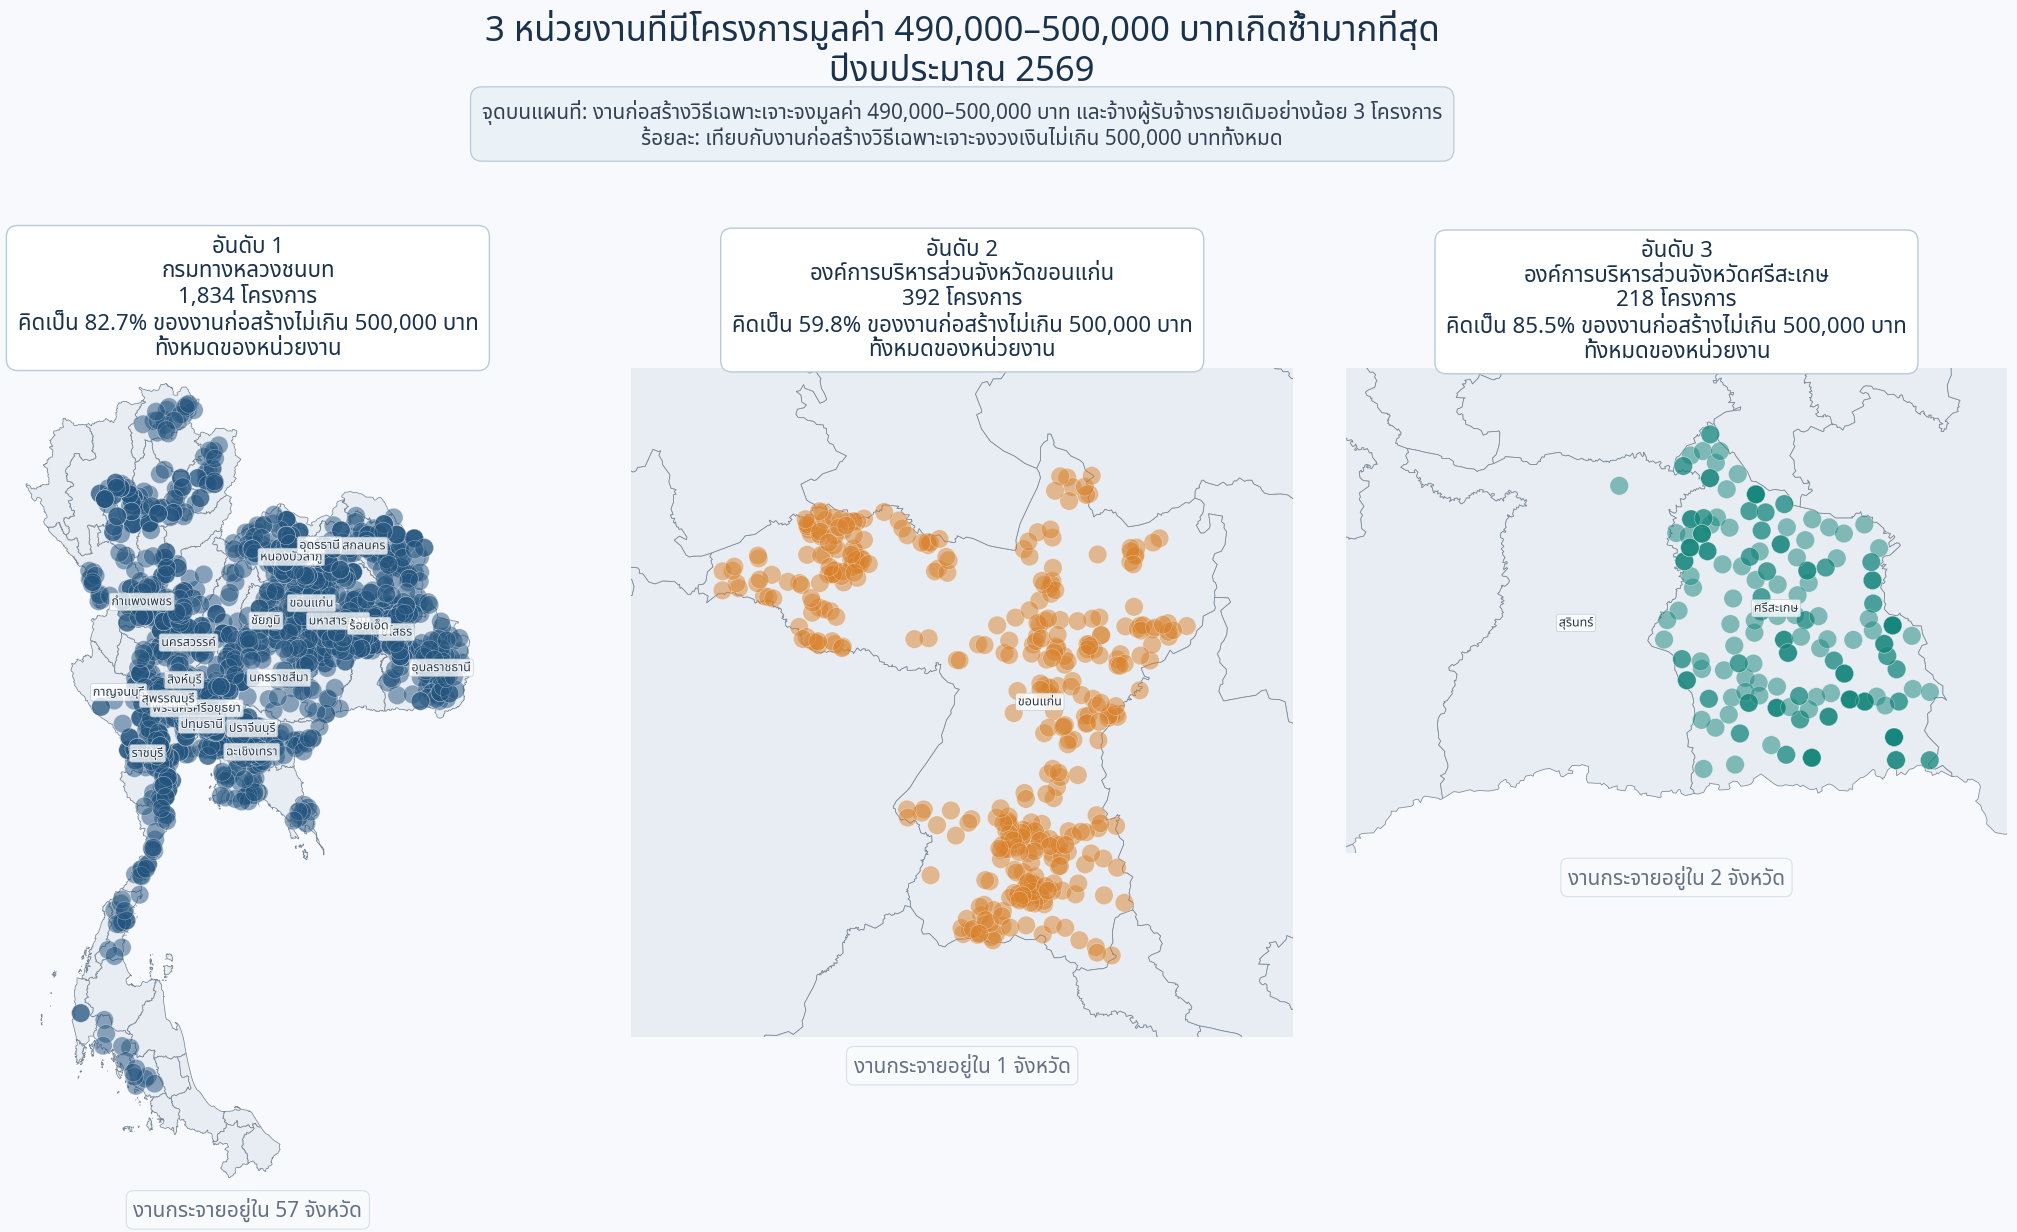

In [35]:
# ============================================================
# 8) MAP 1 : หน่วยงาน Top 3 ตามจำนวนรายการ Pattern 1
# ============================================================

def add_thailand_base(ax, plot_df):
    # วาด GeoJSON ทั้งประเทศก่อน แล้วกำหนดขอบเขตจาก Min/Max ของจุดใน subplot นั้น
    thai_provinces.plot(
        ax=ax, color=MAP_FILL, edgecolor=BOUNDARY_COLOR,
        linewidth=0.55, zorder=1,
    )

    full_minx, full_miny, full_maxx, full_maxy = thai_provinces.total_bounds
    if plot_df.empty:
        view_minx, view_miny, view_maxx, view_maxy = (
            full_minx, full_miny, full_maxx, full_maxy
        )
    else:
        # เริ่มจาก Min/Max Longitude–Latitude ของจุดจริง
        point_minx = float(plot_df['longitude'].min())
        point_maxx = float(plot_df['longitude'].max())
        point_miny = float(plot_df['latitude'].min())
        point_maxy = float(plot_df['latitude'].max())

        # รวมขอบเขต polygon ของจังหวัดที่ Spatial Join พบ เพื่อไม่ซูมเล็กกว่าจังหวัดมากเกินไป
        province_names = plot_df['coordinate_province'].dropna().unique().tolist()
        related_provinces = thai_provinces.loc[
            thai_provinces['coordinate_province'].isin(province_names)
        ]
        if not related_provinces.empty:
            province_minx, province_miny, province_maxx, province_maxy = related_provinces.total_bounds
            point_minx = min(point_minx, float(province_minx))
            point_miny = min(point_miny, float(province_miny))
            point_maxx = max(point_maxx, float(province_maxx))
            point_maxy = max(point_maxy, float(province_maxy))

        center_x = (point_minx + point_maxx) / 2
        center_y = (point_miny + point_maxy) / 2
        span_x = max(point_maxx - point_minx, MIN_ZOOM_SPAN_LONGITUDE)
        span_y = max(point_maxy - point_miny, MIN_ZOOM_SPAN_LATITUDE)
        padding_x = max(span_x * ZOOM_PADDING_RATIO, ZOOM_PADDING_DEGREES)
        padding_y = max(span_y * ZOOM_PADDING_RATIO, ZOOM_PADDING_DEGREES)

        view_minx = max(center_x - span_x / 2 - padding_x, full_minx - 0.30)
        view_maxx = min(center_x + span_x / 2 + padding_x, full_maxx + 0.30)
        view_miny = max(center_y - span_y / 2 - padding_y, full_miny - 0.30)
        view_maxy = min(center_y + span_y / 2 + padding_y, full_maxy + 0.30)

    ax.set_xlim(view_minx, view_maxx)
    ax.set_ylim(view_miny, view_maxy)
    ax.set_aspect('equal', adjustable='box')
    ax.set_anchor('N')
    ax.set_axis_off()
    return {
        'minx': view_minx, 'maxx': view_maxx,
        'miny': view_miny, 'maxy': view_maxy,
    }


def add_province_labels(ax, plot_df):
    # แสดงชื่อจังหวัดที่มีจุด โดยเรียงจากจังหวัดที่มีจุดมากที่สุด
    province_counts = plot_df['coordinate_province'].dropna().value_counts()
    total_provinces = int(len(province_counts))
    selected_names = province_counts.head(MAX_PROVINCE_LABELS).index.tolist()
    label_provinces = thai_provinces.loc[
        thai_provinces['coordinate_province'].isin(selected_names)
    ].copy()
    if label_provinces.empty:
        return 0, total_provinces

    # representative_point อยู่ภายใน polygon จึงเหมาะกว่าการใช้ centroid กับจังหวัดรูปทรงเว้า
    label_provinces['label_point'] = label_provinces.geometry.representative_point()
    for _, province_row in label_provinces.iterrows():
        label_point = province_row['label_point']
        label_text = ax.text(
            label_point.x, label_point.y,
            province_row['coordinate_province'],
            ha='center', va='center',
            fontsize=PROVINCE_LABEL_SIZE, fontweight='bold',
            color='#263849', zorder=6,
            bbox={
                'boxstyle': 'round,pad=0.18',
                'facecolor': 'white',
                'edgecolor': '#AAB8C4',
                'linewidth': 0.45,
                'alpha': 0.78,
            },
        )
        label_text.set_path_effects([
            path_effects.withStroke(linewidth=1.1, foreground='white')
        ])
    return int(len(label_provinces)), total_provinces


def add_figure_header(fig, title, subtitle, title_y=0.975, subtitle_y=0.890):
    # แยก Title หลักและ Subtitle เป็นคนละแถบ ไม่ให้ชนกับหัวของแต่ละ subplot
    fig.suptitle(
        title, fontsize=25, fontweight='bold', color=TITLE_COLOR, y=title_y,
    )
    fig.text(
        0.5, subtitle_y, subtitle,
        ha='center', va='center', fontsize=15, color=TEXT_COLOR, linespacing=1.20,
        bbox={
            'boxstyle': 'round,pad=0.55',
            'facecolor': '#EAF2F8',
            'edgecolor': '#B9CAD8',
            'linewidth': 0.9,
        },
    )


def add_panel_title(ax, text, y=1.010):
    # ใช้กล่องหัว subplot แยกจากพื้นที่แผนที่ และเพิ่มระยะระหว่างบรรทัด
    ax.text(
        0.5, y, text,
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=16, fontweight='bold', color=TITLE_COLOR,
        linespacing=1.22, clip_on=False,
        bbox={
            'boxstyle': 'round,pad=0.50',
            'facecolor': 'white',
            'edgecolor': '#B9CAD8',
            'linewidth': 1.0,
        },
    )


def add_panel_note(ax, text, y=-0.025):
    # แยกหมายเหตุใต้แผนที่ออกจาก Legend ส่วนกลาง
    ax.text(
        0.5, y, text,
        transform=ax.transAxes, ha='center', va='top',
        fontsize=15, color=MUTED_COLOR, linespacing=1.25,
        clip_on=False,
        bbox={
            'boxstyle': 'round,pad=0.34',
            'facecolor': '#F8FAFC',
            'edgecolor': '#D7E0E8',
            'linewidth': 0.8,
        },
    )


fig, axes = plt.subplots(1, 3, figsize=(22, 13.5), facecolor=BACKGROUND)
for index, (_, row) in enumerate(top3_agency_pattern1_df.iterrows()):
    ax = axes[index]
    color = ENTITY_COLORS[index]
    agency = row['agency']
    plot_df = pattern1_spatial_gdf.loc[pattern1_spatial_gdf['agency'].eq(agency)].sort_values(
        'amount', ascending=False
    )
    add_thailand_base(ax, plot_df)
    ax.scatter(
        plot_df['longitude'], plot_df['latitude'], s=plot_df['marker_area'],
        color=color, alpha=0.50, edgecolors='white', linewidths=0.35, zorder=4,
    )
    _, province_total = add_province_labels(ax, plot_df)
    add_panel_title(
        ax,
        f"อันดับ {int(row['อันดับ'])}\n{wrap_label(agency, 24)}\n"
        f"{int(row['pattern1_count']):,} โครงการ\n"
        f"คิดเป็น {row['pattern1_share_pct']:.1f}% ของงานก่อสร้างไม่เกิน 500,000 บาท\nทั้งหมดของหน่วยงาน",
    )
    add_panel_note(
        ax, f"งานกระจายอยู่ใน {province_total:,} จังหวัด", y=-0.025,
    )

add_figure_header(
    fig,
    f'3 หน่วยงานที่มีโครงการมูลค่า 490,000–500,000 บาทเกิดซ้ำมากที่สุด\nปีงบประมาณ {YEAR}',
    'จุดบนแผนที่: งานก่อสร้างวิธีเฉพาะเจาะจงมูลค่า 490,000–500,000 บาท และจ้างผู้รับจ้างรายเดิมอย่างน้อย 3 โครงการ\nร้อยละ: เทียบกับงานก่อสร้างวิธีเฉพาะเจาะจงวงเงินไม่เกิน 500,000 บาททั้งหมด',
)
plt.subplots_adjust(left=0.025, right=0.975, top=0.710, bottom=0.110, wspace=0.08)
save_and_show(fig, f'01_top3_agencies_pattern1_longlat_{YEAR}')


## 8. แผนที่ผู้รับจ้าง Top 3 ตามจำนวน Pattern 1

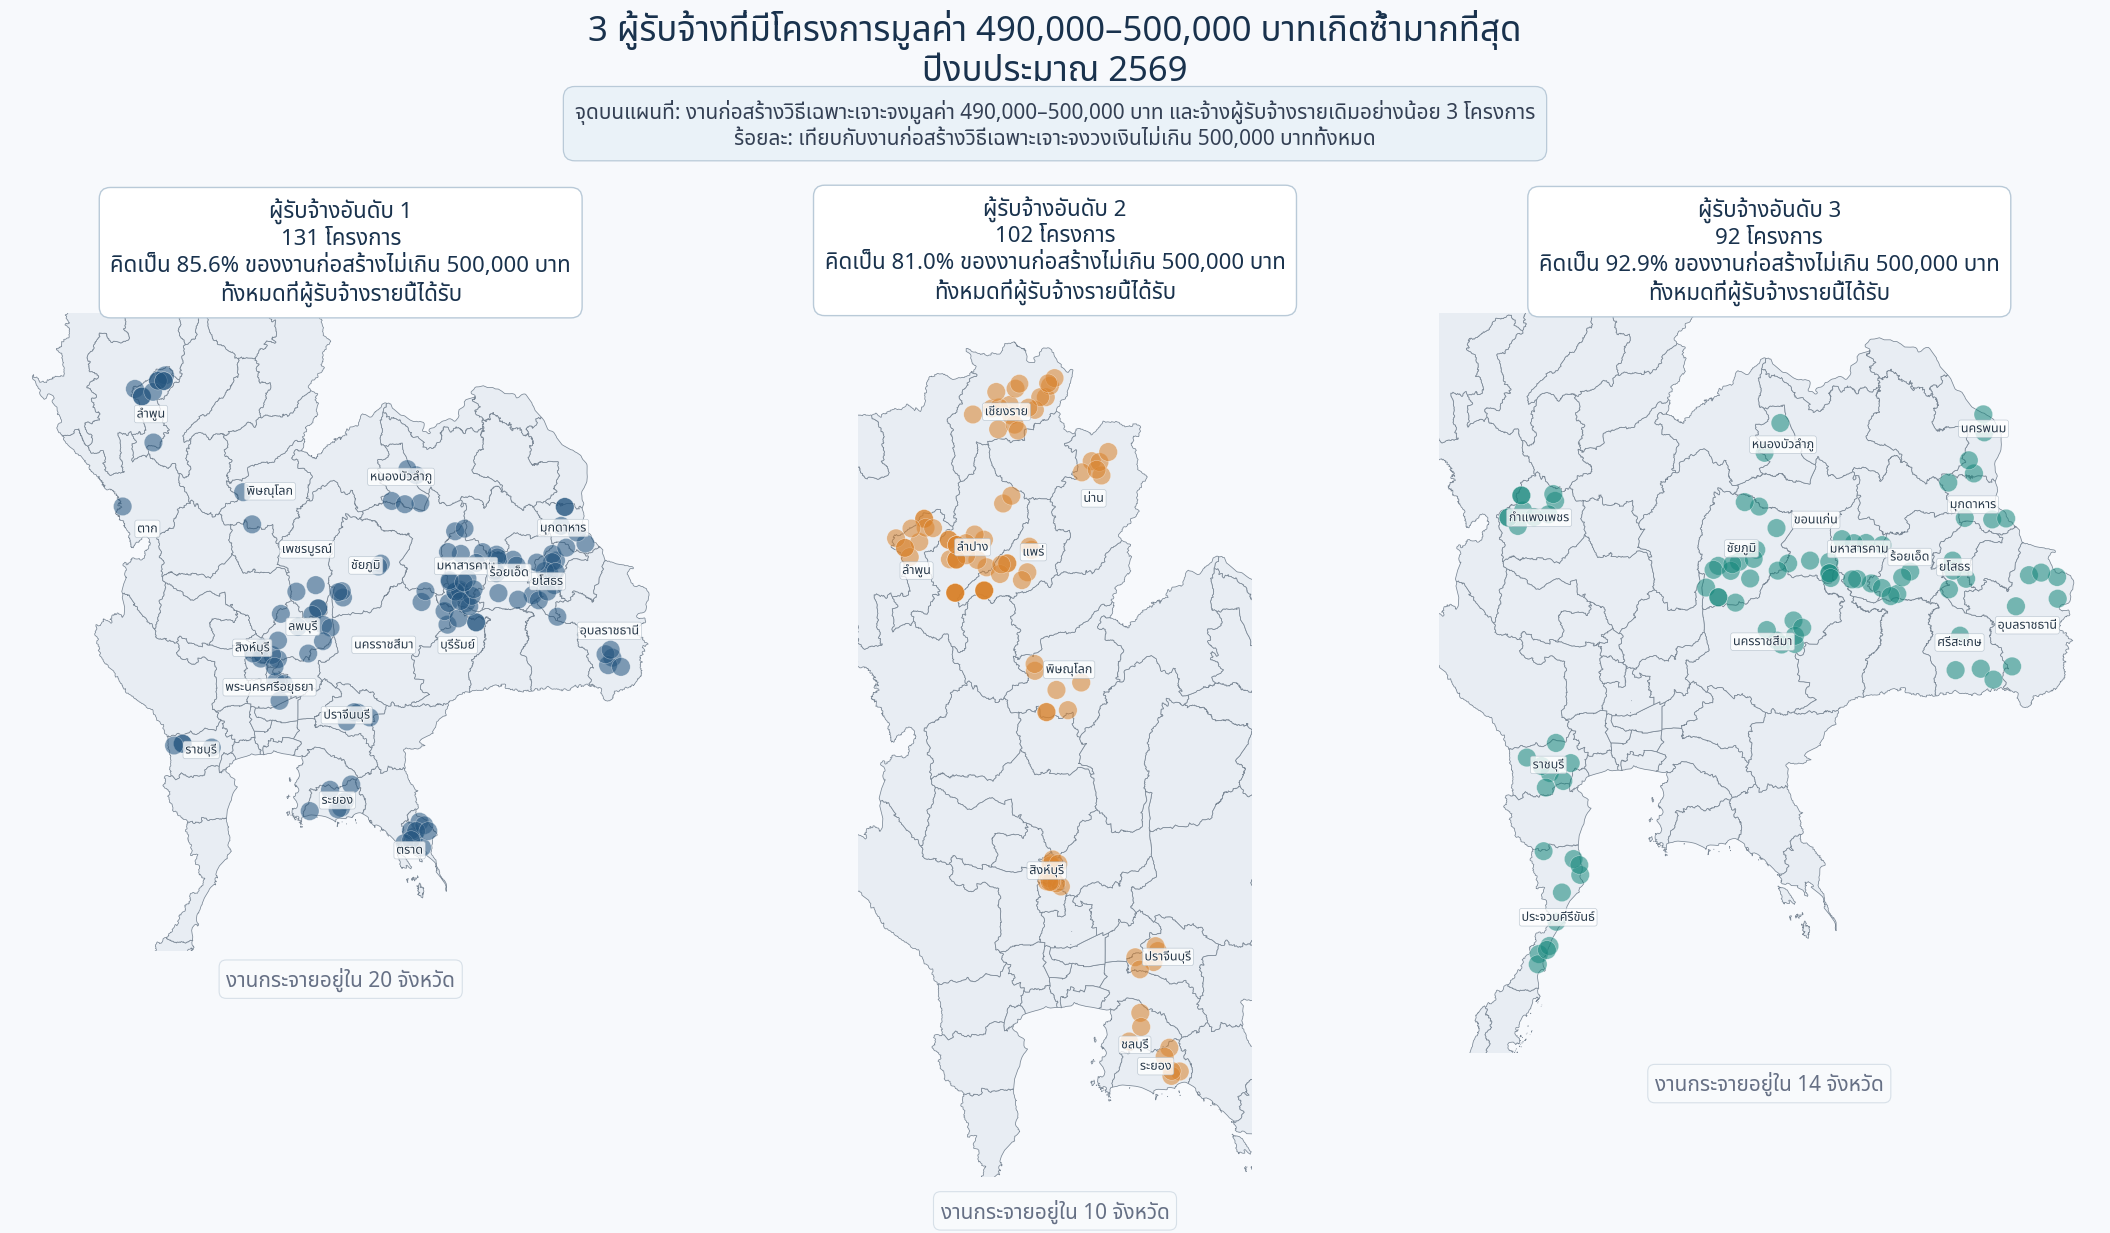

In [36]:
# ============================================================
# 9) MAP 2 : ผู้รับจ้าง Top 3 ตามจำนวนรายการ Pattern 1
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 13.5), facecolor=BACKGROUND)
for index, (_, row) in enumerate(top3_supplier_pattern1_df.iterrows()):
    ax = axes[index]
    color = ENTITY_COLORS[index]
    supplier_key = row['supplier_key']
    plot_df = pattern1_spatial_gdf.loc[
        pattern1_spatial_gdf['supplier_key'].eq(supplier_key)
    ].sort_values('amount', ascending=False)
    add_thailand_base(ax, plot_df)
    ax.scatter(
        plot_df['longitude'], plot_df['latitude'], s=plot_df['marker_area'],
        color=color, alpha=0.55, edgecolors='white', linewidths=0.35, zorder=4,
    )
    _, province_total = add_province_labels(ax, plot_df)
    add_panel_title(
        ax,
        f"ผู้รับจ้างอันดับ {int(row['อันดับ'])}\n"
        f"{int(row['pattern1_count']):,} โครงการ\n"
        f"คิดเป็น {row['pattern1_share_pct']:.1f}% ของงานก่อสร้างไม่เกิน 500,000 บาท\nทั้งหมดที่ผู้รับจ้างรายนี้ได้รับ",
    )
    add_panel_note(
        ax, f"งานกระจายอยู่ใน {province_total:,} จังหวัด", y=-0.025,
    )

add_figure_header(
    fig,
    f'3 ผู้รับจ้างที่มีโครงการมูลค่า 490,000–500,000 บาทเกิดซ้ำมากที่สุด\nปีงบประมาณ {YEAR}',
    'จุดบนแผนที่: งานก่อสร้างวิธีเฉพาะเจาะจงมูลค่า 490,000–500,000 บาท และจ้างผู้รับจ้างรายเดิมอย่างน้อย 3 โครงการ\nร้อยละ: เทียบกับงานก่อสร้างวิธีเฉพาะเจาะจงวงเงินไม่เกิน 500,000 บาททั้งหมด',
)
plt.subplots_adjust(left=0.025, right=0.975, top=0.750, bottom=0.110, wspace=0.08)
save_and_show(fig, f'02_top3_suppliers_pattern1_longlat_{YEAR}')


## 9. หน่วยงานมูลค่าสูง Top 3 และผู้รับจ้างที่เกิดซ้ำภายในหน่วยงาน

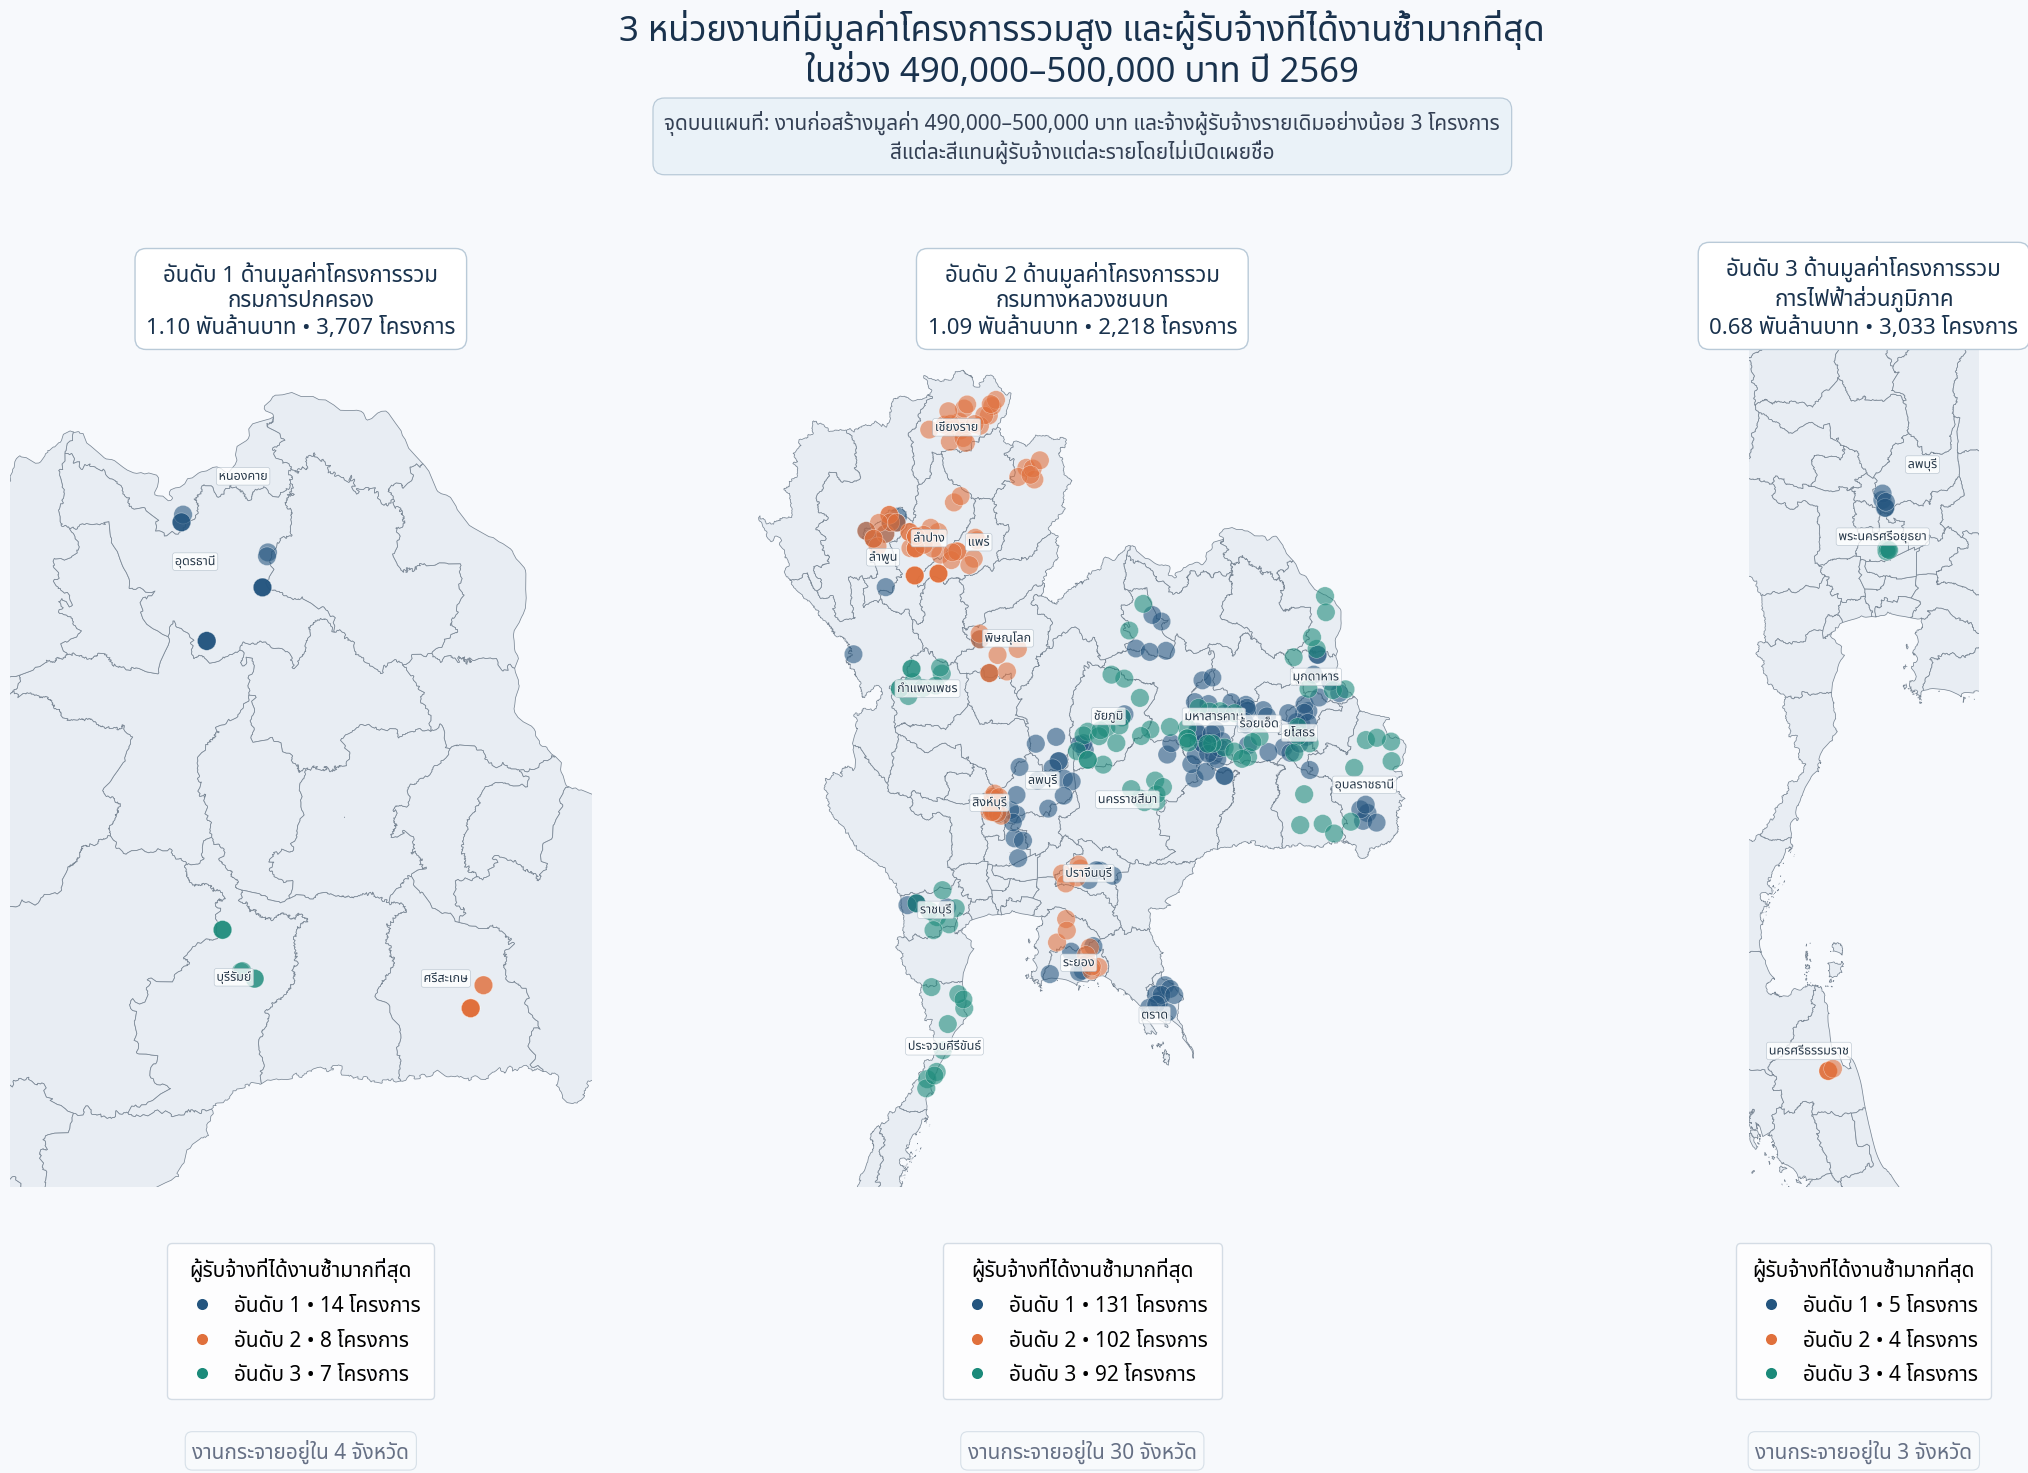

In [37]:
# ============================================================
# 10) MAP 3 : หน่วยงานมูลค่ารวมสูง Top 3 และผู้รับจ้าง Pattern 1 Top 3
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(24, 15), facecolor=BACKGROUND)
for axis_index, (_, agency_row) in enumerate(top3_agency_value_df.iterrows()):
    ax = axes[axis_index]
    agency = agency_row['agency']
    selected_suppliers = (
        top3_suppliers_by_top_agency_df.loc[
            top3_suppliers_by_top_agency_df['agency'].eq(agency)
        ].sort_values('supplier_rank')
    )
    selected_supplier_keys = selected_suppliers['supplier_key'].tolist()
    panel_plot_df = pattern1_spatial_gdf.loc[
        pattern1_spatial_gdf['agency'].eq(agency)
        & pattern1_spatial_gdf['supplier_key'].isin(selected_supplier_keys)
    ].copy()
    add_thailand_base(ax, panel_plot_df)
    legend_handles = []
    for supplier_index, (_, supplier_row) in enumerate(selected_suppliers.iterrows()):
        color = SUPPLIER_COLORS[supplier_index]
        plot_df = panel_plot_df.loc[
            panel_plot_df['supplier_key'].eq(supplier_row['supplier_key'])
        ].sort_values('amount', ascending=False)
        ax.scatter(
            plot_df['longitude'], plot_df['latitude'], s=plot_df['marker_area'],
            color=color, alpha=0.58, edgecolors='white', linewidths=0.35, zorder=4,
        )
        legend_handles.append(Line2D(
            [0], [0], marker='o', linestyle='none', markersize=9,
            markerfacecolor=color, markeredgecolor='white',
            label=(
                f"อันดับ {int(supplier_row['supplier_rank'])} • {int(supplier_row['pattern1_count']):,} โครงการ"
            ),
        ))

    _, province_total = add_province_labels(ax, panel_plot_df)
    add_panel_title(
        ax,
        f"อันดับ {int(agency_row['อันดับ'])} ด้านมูลค่าโครงการรวม\n{wrap_label(agency, 26)}\n"
        f"{agency_row['scope_value'] / 1e9:,.2f} พันล้านบาท • {int(agency_row['scope_count']):,} โครงการ",
    )
    ax.legend(
        handles=legend_handles, title='ผู้รับจ้างที่ได้งานซ้ำมากที่สุด',
        loc='upper center', bbox_to_anchor=(0.5, -0.055),
        frameon=True, facecolor='white', edgecolor='#CBD5DF',
        labelspacing=0.65, borderpad=0.65, handletextpad=0.55,
    )
    add_panel_note(
        ax, f"งานกระจายอยู่ใน {province_total:,} จังหวัด", y=-0.3, ############
    )

add_figure_header(
    fig,
    f'3 หน่วยงานที่มีมูลค่าโครงการรวมสูง และผู้รับจ้างที่ได้งานซ้ำมากที่สุด\nในช่วง 490,000–500,000 บาท ปี {YEAR}',
    'จุดบนแผนที่: งานก่อสร้างมูลค่า 490,000–500,000 บาท และจ้างผู้รับจ้างรายเดิมอย่างน้อย 3 โครงการ\nสีแต่ละสีแทนผู้รับจ้างแต่ละรายโดยไม่เปิดเผยชื่อ',
)
plt.subplots_adjust(left=0.025, right=0.975, top=0.750, bottom=0.190, wspace=0.09)
save_and_show(fig, f'03_top_value_agencies_top3_pattern1_suppliers_{YEAR}')


## 10. แนวทางอ่านกราฟ

- จุดจำนวนมากในหลายจังหวัดสะท้อนการกระจายเชิงภูมิศาสตร์ ส่วนจุดกระจุกในพื้นที่เล็กสะท้อนความเข้มข้นของตำแหน่งงานที่ควรตรวจบริบทเพิ่ม
- จำนวน Pattern 1 สูงต้องอ่านร่วมกับ `pattern1_share_pct` เพราะหน่วยงานขนาดใหญ่ย่อมมีโอกาสพบจำนวนมากกว่า
- วงกลมใช้ “พื้นที่” แปรผันตามวงเงิน แต่เนื่องจาก Pattern 1 อยู่เพียงช่วง 490,000–500,000 บาท ความต่างของขนาดจุดจึงควรมีเพียงเล็กน้อย
- ควรเปิดเอกสาร TOR/BOQ สถานที่จริง วันที่ และเหตุผลการแยกโครงการก่อนสรุปเชิงพฤติกรรม


In [38]:
# ============================================================
# 11) FINAL CHECKS AND CLEANUP : เก็บ DataFrame หลักและปิด Figure
# ============================================================

final_summary_df = pd.DataFrame({
    'ผลลัพธ์': [
        'กลุ่มศึกษา', 'Pattern 1', 'Pattern 2', 'Priority P1 AND P2',
        'Pattern 1 ที่มีพิกัดใน BBox ไทย',
    ],
    'จำนวนรายการ': [
        len(study_df),
        int(study_df['flag_pattern_1'].sum()),
        int(study_df['flag_pattern_2'].sum()),
        int(study_df['priority_p1_and_p2'].sum()),
        len(pattern1_spatial_gdf),
    ],
})
display(final_summary_df.style.format({'จำนวนรายการ': '{:,.0f}'}))

print('\nDataFrame ที่เก็บไว้สำหรับตรวจย้อนกลับ:')
print('- study_df : กลุ่มศึกษาจาก Review Indicators')
print('- pattern1_df : รายการ Pattern 1 ก่อนตรวจพิกัด')
print('- pattern2_pairs_df : คู่หน่วยงาน–ผู้รับจ้างที่ผ่านเกณฑ์ Pattern 2')
print('- exported_flag_reconciliation_df : ตารางเทียบ Flag เดิมกับผลคำนวณใหม่')
print('- pattern1_spatial_gdf : Pattern 1 หลังตรวจ Long/Lat และ Spatial Join')
print('- agency_ranking_df / supplier_ranking_df : ตารางอันดับทั้งหมด')
print('- top3_agency_pattern1_df / top3_supplier_pattern1_df : Top 3 สำหรับแผนที่ 1–2')
print('- top3_agency_value_df / top3_suppliers_by_top_agency_df : Top 3 สำหรับแผนที่ 3')
print('- thai_provinces : GeoJSON จังหวัดประเทศไทย')

# ลบเฉพาะ Object ชั่วคราว ไม่ลบ DataFrame หลักที่ใช้ย้อนกลับ
for temporary_name in ['valid_points_df', 'top_supplier_parts', 'swapped_mask']:
    globals().pop(temporary_name, None)
plt.close('all')
gc.collect()

print_memory('เมื่อจบ Notebook')
print('✅ ปิด Figure ทั้งหมดแล้ว')
print('✅ ไม่มี worker, executor, database connection หรือ background subprocess')
print('✅ ไม่ได้บันทึก DataFrame/CSV เพิ่ม')
print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")


,ผลลัพธ์,จำนวนรายการ
0,กลุ่มศึกษา,"136,122"
1,Pattern 1,"9,413"
2,Pattern 2,"1,915"
3,Priority P1 AND P2,205
4,Pattern 1 ที่มีพิกัดใน BBox ไทย,"9,311"



DataFrame ที่เก็บไว้สำหรับตรวจย้อนกลับ:
- study_df : กลุ่มศึกษาจาก Review Indicators
- pattern1_df : รายการ Pattern 1 ก่อนตรวจพิกัด
- pattern2_pairs_df : คู่หน่วยงาน–ผู้รับจ้างที่ผ่านเกณฑ์ Pattern 2
- exported_flag_reconciliation_df : ตารางเทียบ Flag เดิมกับผลคำนวณใหม่
- pattern1_spatial_gdf : Pattern 1 หลังตรวจ Long/Lat และ Spatial Join
- agency_ranking_df / supplier_ranking_df : ตารางอันดับทั้งหมด
- top3_agency_pattern1_df / top3_supplier_pattern1_df : Top 3 สำหรับแผนที่ 1–2
- top3_agency_value_df / top3_suppliers_by_top_agency_df : Top 3 สำหรับแผนที่ 3
- thai_provinces : GeoJSON จังหวัดประเทศไทย
RAM เมื่อจบ Notebook: 12.5% | available 11.1 GB
✅ ปิด Figure ทั้งหมดแล้ว
✅ ไม่มี worker, executor, database connection หรือ background subprocess
✅ ไม่ได้บันทึก DataFrame/CSV เพิ่ม
แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์


In [39]:
# คืนพื้นที่ชั่วคราวและปิดรูป โดยเก็บ DataFrame ผลวิเคราะห์ไว้
cleanup_runtime()


ปิดรูปและลบไฟล์พักของ Notebook แล้ว; DataFrame ผลวิเคราะห์ยังอยู่ใน RAM
